<a href="https://colab.research.google.com/github/Usermer/deep-learning-universe/blob/main/computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
from torchvision import transforms
import torchvision
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


**pytorch overview**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
#create a model class that inherits nn.Module
class Model(nn.Module):
  """input layer(4 features of the flower donc 4 neurons ->Hidden layer 1(number of neurons)->
  hidden layer 2 -> output (3 classes of iris floweres) )"""
  def __init__(self,in_features=4,h1=8,h2=8,out_features=3):
    super().__init__()
    self.fc1=nn.Linear(in_features,h1)
    self.fc2=nn.Linear(h1,h2)
    self.out=nn.Linear(h2,out_features)

  def forward(self,x):
    x=F.relu(self.fc1(x))
    x=F.relu(self.fc2(x))
    x=self.out(x)

    return x


In [ ]:
"pick a munual seed for normalization"
torch.manual_seed(42)
model=Model()


In [ ]:
iris = 'http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
df = pd.read_csv(iris, sep=',')
attributes = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]
df.columns = attributes

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


In [ ]:
df['class'].value_counts()

,count
class,
Iris-versicolor,50
Iris-virginica,50
Iris-setosa,49


In [ ]:
df['class']=df['class'].replace('Iris-setosa',0)
df['class']=df['class'].replace('Iris-virginica',1)
df['class']=df['class'].replace('Iris-versicolor',2)

/tmp/ipykernel_21446/2612664060.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['class']=df['class'].replace('Iris-versicolor',2)


In [ ]:
df['class'].value_counts().sort_index()

,count
class,
0,49
1,50
2,50


In [ ]:
#train test split
X=df.drop('class',axis=1)
y=df["class"]

#to convert to numpy array
X=X.values
y=y.values

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#convert features to float  tensors
X_train=torch.FloatTensor(X_train)
X_test=torch.FloatTensor(X_test)
#convert y labels to tensor
y_train=torch.LongTensor(y_train)
y_test=torch.LongTensor(y_test)

In [ ]:
#set the critereon of the model to measure the error ; how far off the predictions are from the data
criterion=nn.CrossEntropyLoss()
#choose optimizer
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)


In [ ]:
model.parameters()

<generator object Module.parameters at 0x7e7d420aa260>

In [ ]:
#train our model
#epochs
epochs=200
losses=[]
for i in range(epochs):
  #go forward and get a prediction
  y_pred=model.forward(X_train)

  #measure the loss/error
  loss=criterion(y_pred,y_train)

  #keep traxk of our losses
  losses.append(loss.detach().numpy())

  #print every 10 epochs
  if i%10==0:
    print("loss:",loss)

  #to so some back propagration
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


loss: tensor(0.2654, grad_fn=<NllLossBackward0>)
loss: tensor(0.1728, grad_fn=<NllLossBackward0>)
loss: tensor(0.1069, grad_fn=<NllLossBackward0>)
loss: tensor(0.0717, grad_fn=<NllLossBackward0>)
loss: tensor(0.0535, grad_fn=<NllLossBackward0>)
loss: tensor(0.0428, grad_fn=<NllLossBackward0>)
loss: tensor(0.0359, grad_fn=<NllLossBackward0>)
loss: tensor(0.0312, grad_fn=<NllLossBackward0>)
loss: tensor(0.0278, grad_fn=<NllLossBackward0>)
loss: tensor(0.0254, grad_fn=<NllLossBackward0>)
loss: tensor(0.0235, grad_fn=<NllLossBackward0>)
loss: tensor(0.0220, grad_fn=<NllLossBackward0>)
loss: tensor(0.0207, grad_fn=<NllLossBackward0>)
loss: tensor(0.0196, grad_fn=<NllLossBackward0>)
loss: tensor(0.0187, grad_fn=<NllLossBackward0>)
loss: tensor(0.0179, grad_fn=<NllLossBackward0>)
loss: tensor(0.0171, grad_fn=<NllLossBackward0>)
loss: tensor(0.0165, grad_fn=<NllLossBackward0>)
loss: tensor(0.0158, grad_fn=<NllLossBackward0>)
loss: tensor(0.0153, grad_fn=<NllLossBackward0>)


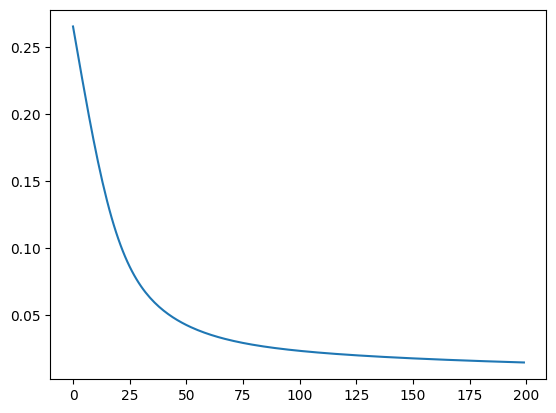

In [ ]:
plt.plot(range(epochs),losses)
plt.show()

**conv2D**

In [ ]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
print(conv_layer)

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


The `nn.Conv2d` layer is a fundamental building block in Convolutional Neural Networks (CNNs). Here's a breakdown of the parameters used:

*   `in_channels`: The number of channels in the input image. For example, an RGB image has 3 channels.
*   `out_channels`: The number of channels produced by the convolution. This is also the number of filters or kernels used.
*   `kernel_size`: The size of the convolutional kernel (or filter). It can be a single integer (e.g., `3` for a 3x3 kernel) or a tuple (e.g., `(3, 3)`).
*   `stride`: The step size of the kernel when moving across the input. A stride of `1` means the kernel moves one pixel at a time. It can also be a tuple.
*   `padding`: The amount of zero-padding added to both sides of the input. `padding=1` with `kernel_size=3` and `stride=1` typically results in output feature maps with the same spatial dimensions as the input.

This `conv_layer` creates a layer that expects an input with 3 channels and will produce an output with 16 channels, using a 3x3 kernel.

**lazyConv2D**

In [ ]:
lazy_conv_layer = nn.LazyConv2d(out_channels=16, kernel_size=3, stride=1, padding=1)
print(lazy_conv_layer)

LazyConv2d(0, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


The `nn.LazyConv2d` layer is a special type of convolutional layer in PyTorch that automatically infers the `in_channels` parameter from the first input it receives during its first forward pass. This is useful when the number of input channels is determined dynamically or is not known at the time of model definition.

Here's a breakdown of the parameters:

*   `out_channels`: The number of channels produced by the convolution. This is similar to `nn.Conv2d`.
*   `kernel_size`: The size of the convolutional kernel.
*   `stride`: The step size of the kernel.
*   `padding`: The amount of zero-padding.

Notice that `in_channels` is *not* provided during initialization. It will be set automatically after the layer processes its first input.

**Pooling**

In [ ]:
pool_layer = nn.MaxPool2d(kernel_size=2, stride=2)
print(pool_layer)

MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


Pooling layers are typically used in CNNs to reduce the spatial dimensions (width and height) of the feature maps, which helps to reduce the number of parameters and computation in the network, and makes the model more robust to variations in object position. `nn.MaxPool2d` performs max pooling.

Here's a breakdown of the parameters for `nn.MaxPool2d`:

*   `kernel_size`: The size of the window to take a max over. A `kernel_size=2` means a 2x2 window.
*   `stride`: The step size of the window. A `stride=2` means the window moves 2 pixels at a time, effectively halving the spatial dimensions of the input feature map.

**data augmentation**

In [ ]:
train_data=torchvision.datasets.CIFAR10(train=True,root='/content/sample_data',download=True)

In [ ]:
train_data.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

<PIL.Image.Image image mode=RGB size=32x32 at 0x79B8D9C47650>


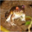

In [ ]:
image,label=train_data[0]
print(image) #3 channels 32x32
image

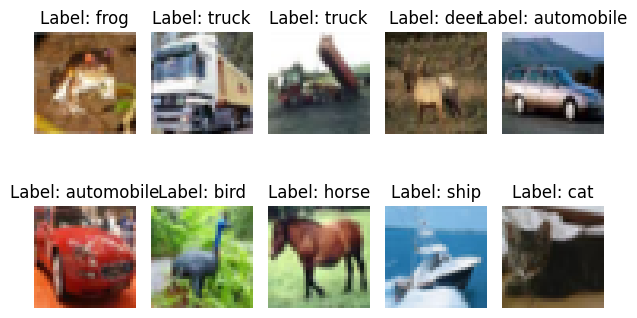

In [ ]:
plt.figure(figsize=(6, 4))
for i in range(10):
    image, label = train_data[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(f"Label: {train_data.classes[label]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
train_augs=transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor()
])
test_augs=transforms.Compose([
    transforms.ToTensor() #on applique pas la data augmentation au test set
])

In [ ]:
def load_cifar(is_train,augs,batch_size):
  dataset=torchvision.datasets.CIFAR10(
      root='/content/sample_data',
      train=is_train,
      transform=augs,
      download=True #si le dataset n'est pas trouve dans le dossier , il va etre telecharge puis stocke depuis internet dans le dossier
  )
  data_loader=torchvision.utils.data.DataLoader(
      dataset,
      batch_size=32,
      shuffle=is_train
  )
  return data_loader